## **DATA INGESTION**

In [1]:
import sys
import os
sys.path.append(os.path.abspath('..'))

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import requests
import warnings
import scipy.stats as stats
from scipy.stats import shapiro, normaltest,zscore
warnings.filterwarnings('ignore')

In [3]:
from scripts.utils import load_historical_data, fetch_live_data, merge_and_clean_data
from scripts.prophet_model import create_prophet_model, train_prophet_model
from scripts.forecast_script import make_forecast, plot_forecast

In [4]:
# Load historical Bitcoin data
historical_btc_df = load_historical_data('../data/bitcoin_historical_data.csv')
historical_btc_df.head()

,ds,y
0,2012-01-01,4.84
1,2012-01-02,5.00
2,2012-01-03,5.29
3,2012-01-04,5.57
4,2012-01-05,6.42


In [5]:
# 2. Fetch live Bitcoin prices from API
live_btc_df = fetch_live_data(days=365, currency='usd')
live_btc_df.head()

,ds,y
0,2024-04-28,63517.248743
1,2024-04-29,63030.433617
2,2024-04-30,63797.679636
3,2024-05-01,60749.472092
4,2024-05-02,58297.574075


In [6]:
# Merge historical and live data
bitcoin_data_df = merge_and_clean_data(historical_btc_df, live_btc_df)
bitcoin_data_df.head()

,ds,y
0,2012-01-01,4.84
1,2012-01-02,5.00
2,2012-01-03,5.29
3,2012-01-04,5.57
4,2012-01-05,6.42


In [7]:
bitcoin_data_df.shape

(4866, 2)

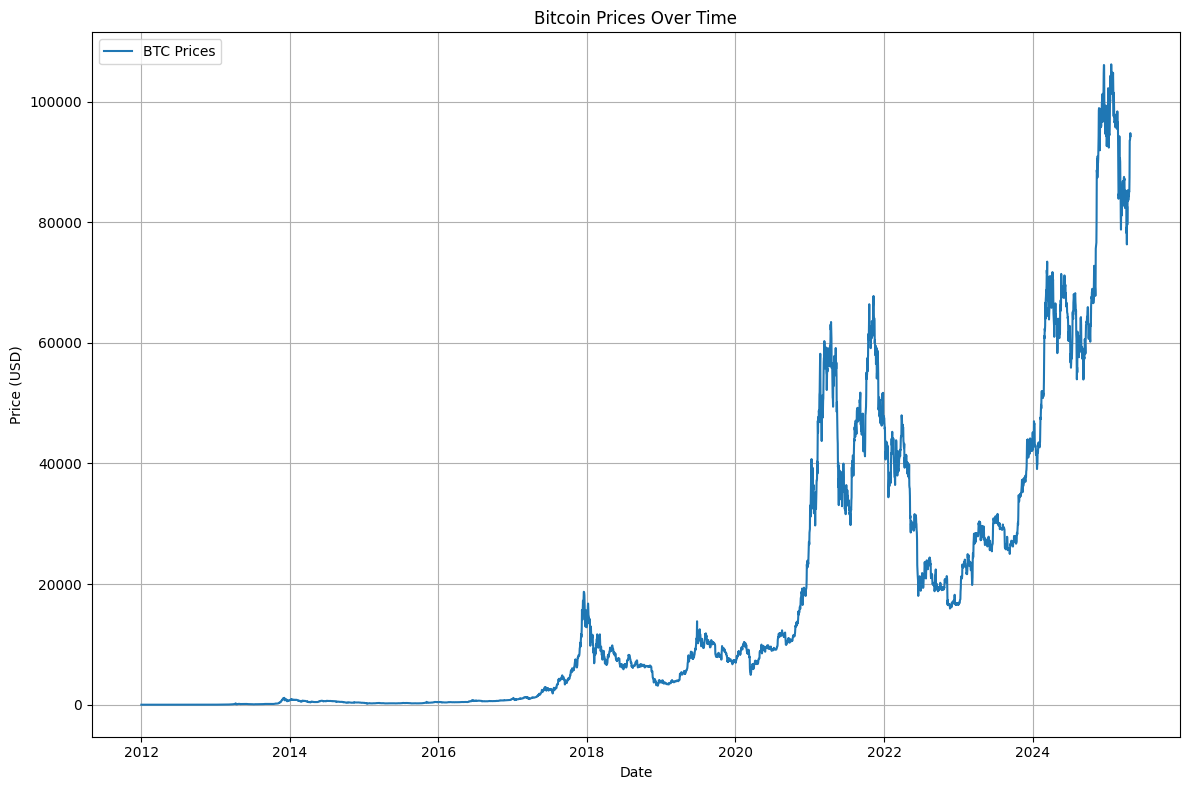

In [8]:
plt.figure(figsize=(12,8))
plt.plot(bitcoin_data_df['ds'], bitcoin_data_df['y'], label='BTC Prices')
plt.title('Bitcoin Prices Over Time')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.grid(True)
plt.legend()  
plt.tight_layout()
plt.show()

## **EXPLORATORY DATA ANALYSIS**

### Dataset Overview

In [9]:
# Time range
print("Start Date:", bitcoin_data_df['ds'].min())
print("End Date:", bitcoin_data_df['ds'].max())

Start Date: 2012-01-01 00:00:00
End Date: 2025-04-27 00:00:00


In [10]:
# Total records 
print("total Daily records:",len(bitcoin_data_df))

total Daily records: 4866


In [11]:
print('Statistics Summary of our Dataset:')
bitcoin_data_df.describe()

Statistics Summary of our Dataset:


,ds,y
count,4866,4866.000000
mean,2018-08-29 12:00:00,17352.898111
min,2012-01-01 00:00:00,4.380000
25%,2015-05-01 06:00:00,424.420000
50%,2018-08-29 12:00:00,6590.490000
75%,2021-12-27 18:00:00,27236.500000
max,2025-04-27 00:00:00,106182.236820
std,NaN,23976.929489


### DATA QUALITY CHECKS

In [12]:
print("The number of missing entries:")
bitcoin_data_df.isnull().sum()

The number of missing entries:


ds    0
y     0
dtype: int64

In [13]:
# Check for missing days (gap in timeline)
expected_dates = pd.date_range(start=bitcoin_data_df['ds'].min(), end=bitcoin_data_df['ds'].max(), freq='D')
actual_dates = pd.to_datetime(bitcoin_data_df['ds'])
missing_days = expected_dates.difference(actual_dates)
print(f"\nNumber of missing days: {len(missing_days)}")
if len(missing_days) > 0:
    print("Missing dates:", missing_days[:5])


Number of missing days: 0


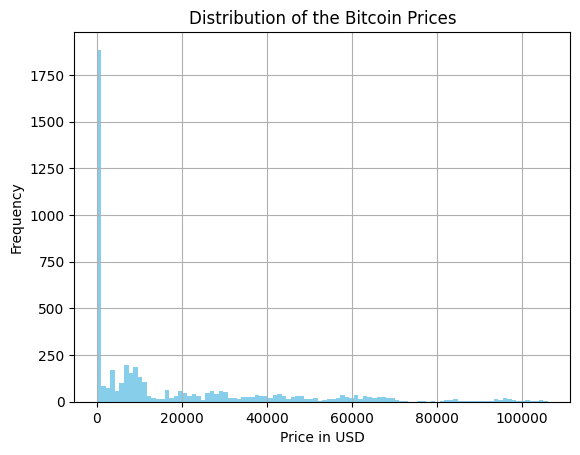

In [14]:
# understanding distribution of the data
plt.hist(bitcoin_data_df['y'],bins=100,color='skyblue')
plt.title('Distribution of the Bitcoin Prices')
plt.xlabel('Price in USD')
plt.ylabel('Frequency')
plt.grid(True)

Text(0.5, 1.0, 'QQ Plot for the bitcoin Prices')

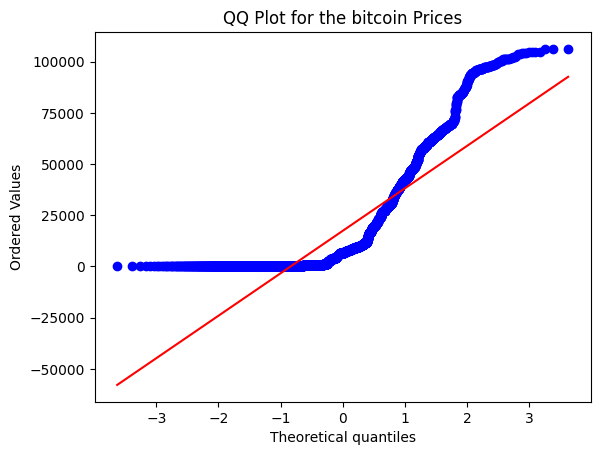

In [15]:
stats.probplot(bitcoin_data_df['y'], dist="norm",plot=plt)
plt.title("QQ Plot for the bitcoin Prices")

The QQ plot shows that Bitcoin prices are **not normally distributed**, with heavy right skew and extreme outliers. This is typical for financial time series and justifies using models like **Prophet**, which don't assume normality.